<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/material/corrosionandthermo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CO₂ corrosion, inhibition, and pipeline integrity with NeqSim

This notebook develops a reproducible corrosion-screening workflow for wet oil-and-gas
production systems. It links electrolyte thermodynamics, aqueous speciation, empirical and
mechanistic corrosion models, inhibitor performance, material selection, and flowline hydraulics.

**Audience.** Corrosion, materials, production, flow-assurance, and process engineers.

**Prerequisites.** Basic phase equilibrium, electrochemistry, fluid flow, and Python. All inputs
are public synthetic data. Pressure is absolute and displayed quantities use SI engineering units.

## Learning objectives

After completing the notebook, you will be able to:

1. represent a wet, saline CO₂-containing fluid with Electrolyte-CPA;
2. perform a reactive multiphase TP flash and retrieve aqueous pH and ionic composition;
3. distinguish thermodynamic scale tendency from corrosion rate;
4. screen CO₂ corrosion with NeqSim's thermodynamic analyzer and NORSOK M-506 model;
5. explain kinetic, mass-transfer, and mixed-control corrosion;
6. evaluate film-forming inhibitor dose and temperature sensitivity;
7. screen material and sour-service implications;
8. couple a Beggs–Brill flowline calculation to a segment-by-segment integrity assessment; and
9. verify results with applicability, trend, and consistency checks.

## Engineering workflow

The central requirement for internal aqueous corrosion is **free water contacting the metal**.
The workflow therefore begins with phase equilibrium, not a corrosion-rate correlation.

`fluid and ions → reactive TP flash → free-water and pH check → corrosion models → inhibition →
material screen → hydraulic profile → segment integrity`

NeqSim represents the fluid with a thermodynamic system. Streams carry that system into unit
operations such as a pipe. Each unit is run before its outlet or profiles are read. Corrosion
classes then consume local pressure, temperature, composition, pH, and velocity.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

print("NeqSim is available in this runtime.")

NeqSim is available in this runtime.


In [2]:
import importlib.metadata
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from neqsim import jneqsim
from neqsim.process import beggs_brill_pipe, stream
from neqsim.thermo import TPflash, calcIonComposition, checkScalePotential, fluid

NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "grey": "#666666",
}

plt.rcParams.update(
    {
        "figure.figsize": (8.6, 4.8),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

print(f"NeqSim {NEQSIM_VERSION}")
print(f"Python {PYTHON_VERSION}")
print(JAVA_VERSION)

NeqSim 3.16.0
Python 3.12.13
openjdk version "17.0.19" 2026-04-21


## Design basis, assumptions, and validity

The base electrolyte case represents a methane-rich gas in contact with saline water at
**80 bara** and **60 °C**. The final application is a **20 km**, **0.30 m** internal-diameter
wet-gas flowline carrying **20 kg/s** from **120 bara** and **60 °C**.

Assumptions:

- local thermodynamic equilibrium and steady flow;
- carbon-steel internal corrosion dominated by aqueous CO₂;
- uniform wall exposure, with no localized-corrosion multiplier;
- specified bulk inhibitor efficiency or a calibrated adsorption model;
- no oxygen ingress, microbiologically influenced corrosion, erosion, or solids deposition;
- synthetic water chemistry and fluid composition.

NORSOK M-506 screening is intended for carbon steel with free water, approximately **5–150 °C**,
CO₂ partial pressure up to **10 bar**, and pH approximately **3.5–6.5**. Project design requires
qualified laboratory data, inspection history, inhibitor availability, transient analysis, and
the governing company and regulatory standards.

In [3]:
ELECTROLYTE_TEMPERATURE_C = 60.0
ELECTROLYTE_PRESSURE_BARA = 80.0
PIPE_LENGTH_M = 20_000.0
PIPE_DIAMETER_M = 0.30
PIPE_FEED_RATE_KG_S = 20.0
DESIGN_LIFE_YEARS = 25.0

gas_component_amounts = {
    "nitrogen": 1.0,
    "CO2": 1.1,
    "methane": 88.3,
    "ethane": 5.0,
    "propane": 1.5,
}
ion_rates_mol_s = {
    "Na+": 0.025,
    "Cl-": 0.025,
    "Ca++": 0.00025,
    "Fe++": 0.00025,
    "OH-": 0.00025,
}

assert PIPE_LENGTH_M > 0.0
assert PIPE_DIAMETER_M > 0.0
assert PIPE_FEED_RATE_KG_S > 0.0
assert np.isclose(
    gas_component_amounts["CO2"],
    1.1,
)

basis = pd.DataFrame(
    {
        "Quantity": [
            "Electrolyte temperature",
            "Electrolyte pressure",
            "Flowline length",
            "Flowline internal diameter",
            "Flowline feed mass rate",
            "Design life",
        ],
        "Value": [
            ELECTROLYTE_TEMPERATURE_C,
            ELECTROLYTE_PRESSURE_BARA,
            PIPE_LENGTH_M,
            PIPE_DIAMETER_M,
            PIPE_FEED_RATE_KG_S,
            DESIGN_LIFE_YEARS,
        ],
        "Unit": ["°C", "bara", "m", "m", "kg/s", "yr"],
    }
)
display(basis)

                     Quantity    Value  Unit
0     Electrolyte temperature     60.0    °C
1        Electrolyte pressure     80.0  bara
2             Flowline length  20000.0     m
3  Flowline internal diameter      0.3     m
4     Flowline feed mass rate     20.0  kg/s
5                 Design life     25.0    yr


## Electrochemical reactions

At an anodic site, iron dissolves:

$$
\mathrm{Fe}\rightarrow \mathrm{Fe}^{2+}+2e^-
$$

In oxygenated water, a possible cathodic reaction is:

$$
\mathrm{O}_2+2\mathrm{H}_2\mathrm{O}+4e^-\rightarrow 4\mathrm{OH}^-
$$

The present numerical model assumes oxygen-free production fluid, so dissolved CO₂ and aqueous
carbonate chemistry control the screening calculation. A film-forming amine can adsorb on steel:

$$
\mathrm{RNH}_2+\mathrm{Fe}\rightarrow [\mathrm{Fe{-}NH_2R}]_{\mathrm{surface}}
$$

An oxygen scavenger such as hydrazine can consume oxygen:

$$
\mathrm{N}_2\mathrm{H}_4+\mathrm{O}_2\rightarrow \mathrm{N}_2+2\mathrm{H}_2\mathrm{O}
$$

An alkaline chemical can neutralize hydrogen sulfide:

$$
2\mathrm{NaOH}+\mathrm{H}_2\mathrm{S}\rightarrow \mathrm{Na}_2\mathrm{S}+2\mathrm{H}_2\mathrm{O}
$$

These equations describe different mitigation mechanisms. They are not interchangeable, and a
film-forming inhibitor efficiency must be supported by representative testing.

## Inhibitor families and corrosion–scale coupling

- **Film-forming inhibitors** adsorb on steel and reduce the active electrochemical area.
- **Scavengers** remove reactive species such as oxygen or hydrogen sulfide.
- **Biocides** control microorganisms associated with microbiologically influenced corrosion.
- **Neutralizing inhibitors** raise pH or neutralize acids.

Scale can either create a partially protective film or generate deposits that promote under-deposit
corrosion. The [Fundamentals of Scale Formation](https://www.youtube.com/watch?v=ahlGXV8tqC8)
video introduces this coupled flow-assurance problem. The thermodynamic scale result below is a
tendency indicator; it does not predict deposition kinetics or protection.

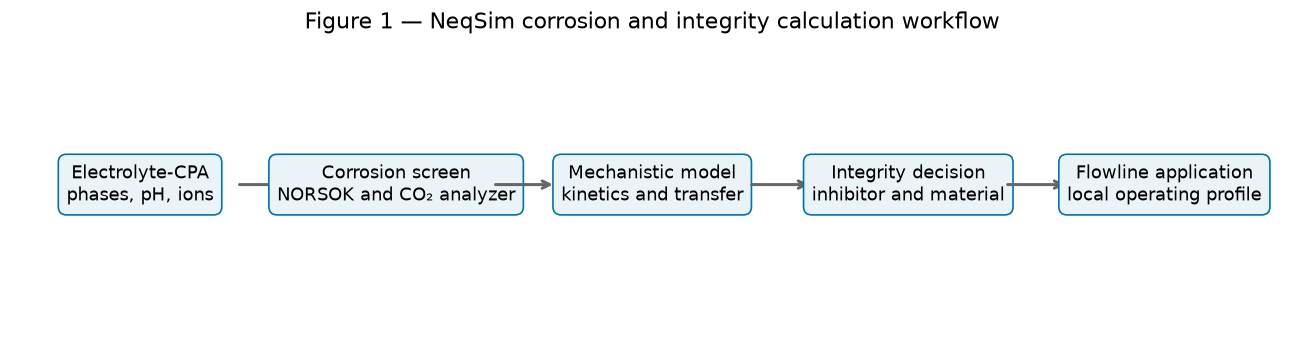

In [4]:
workflow_steps = [
    ("Electrolyte-CPA", "phases, pH, ions"),
    ("Corrosion screen", "NORSOK and CO₂ analyzer"),
    ("Mechanistic model", "kinetics and transfer"),
    ("Integrity decision", "inhibitor and material"),
    ("Flowline application", "local operating profile"),
]

figure, axis = plt.subplots(figsize=(11.0, 3.1))
axis.set_xlim(0.0, 10.0)
axis.set_ylim(0.0, 2.2)
axis.axis("off")

positions = np.linspace(1.0, 9.0, len(workflow_steps))
for index, ((title, subtitle), position) in enumerate(
    zip(workflow_steps, positions)
):
    axis.text(
        position,
        1.2,
        f"{title}\n{subtitle}",
        ha="center",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "#EAF4F8",
            "edgecolor": COLORS["blue"],
        },
    )
    if index < len(workflow_steps) - 1:
        axis.annotate(
            "",
            xy=(positions[index + 1] - 0.75, 1.2),
            xytext=(position + 0.75, 1.2),
            arrowprops={
                "arrowstyle": "->",
                "color": COLORS["grey"],
                "lw": 1.8,
            },
        )

axis.set_title(
    "Figure 1 — NeqSim corrosion and integrity calculation workflow",
    pad=14,
)
plt.tight_layout()
plt.show()

## Electrolyte-CPA representation and TP-flash solver

Electrolyte-CPA combines a cubic equation of state, association for water, ionic interactions, and
chemical reactions. Mixing rule 10 selects NeqSim's electrolyte interaction treatment.
`chemicalReactionInit()` activates aqueous reactions, and `setMultiPhaseCheck(True)` allows a gas
and an aqueous phase to coexist.

At equilibrium, component chemical potentials are equal between phases:

$$
\mu_i^g(T,p,\mathbf{x})=\mu_i^{aq}(T,p,\mathbf{x})
$$

Here $\mu_i$ is chemical potential in J/mol, $T$ is temperature in K, $p$ is absolute pressure in
Pa, and $\mathbf{x}$ is composition. The TP flash solves these equalities together with component
material balances. Physical properties are initialized only after the flash, before density is
read.

In [5]:
electrolyte_system = fluid("Electrolyte-CPA-EoS")

for component_name, component_amount in gas_component_amounts.items():
    electrolyte_system.addComponent(
        component_name,
        component_amount,
    )

electrolyte_system.addComponent(
    "water",
    1.25,
    "kg/sec",
)

for ion_name, ion_rate_mol_s in ion_rates_mol_s.items():
    electrolyte_system.addComponent(
        ion_name,
        ion_rate_mol_s,
        "mol/sec",
    )

electrolyte_system.chemicalReactionInit()
electrolyte_system.setMixingRule(10)
electrolyte_system.setMultiPhaseCheck(True)
electrolyte_system.setTemperature(
    ELECTROLYTE_TEMPERATURE_C,
    "C",
)
electrolyte_system.setPressure(
    ELECTROLYTE_PRESSURE_BARA,
    "bara",
)

TPflash(electrolyte_system)
electrolyte_system.initProperties()

print(
    "Number of equilibrium phases:",
    electrolyte_system.getNumberOfPhases(),
)

Number of equilibrium phases: 2


In [6]:
phase_rows = []
for phase_index in range(electrolyte_system.getNumberOfPhases()):
    phase = electrolyte_system.getPhase(phase_index)
    phase_rows.append(
        {
            "Phase": str(phase.getPhaseTypeName()),
            "Molar phase fraction [-]": float(
                electrolyte_system.getBeta(phase_index)
            ),
            "Density [kg/m³]": float(
                phase.getDensity("kg/m3")
            ),
        }
    )

phase_table = pd.DataFrame(phase_rows)
aqueous_phase = electrolyte_system.getPhase("aqueous")
aqueous_ph = float(aqueous_phase.getpH())

raw_ion_rows = [
    [None if value is None else str(value) for value in row]
    for row in calcIonComposition(electrolyte_system)
]
ion_table = pd.DataFrame(
    raw_ion_rows[1:-1],
    columns=raw_ion_rows[0],
)
ion_table["mmol/kgSolvent"] = pd.to_numeric(
    ion_table["mmol/kgSolvent"]
)
ion_table["mg/kgSolvent"] = pd.to_numeric(
    ion_table["mg/kgSolvent"]
)
ion_table["Act.Coef"] = pd.to_numeric(
    ion_table["Act.Coef"]
)

raw_scale_rows = [
    [None if value is None else str(value) for value in row]
    for row in checkScalePotential(electrolyte_system)
]
scale_table = pd.DataFrame(
    [row[:2] for row in raw_scale_rows[1:]],
    columns=["Salt", "Relative solubility [-]"],
)
scale_table["Relative solubility [-]"] = pd.to_numeric(
    scale_table["Relative solubility [-]"]
)

print(f"Aqueous pH: {aqueous_ph:.4f} [-]")
display(phase_table)
display(ion_table)
display(scale_table)

Aqueous pH: 4.7937 [-]
     Phase  Molar phase fraction [-]  Density [kg/m³]
0      gas                  0.577898        55.387171
1  aqueous                  0.422111       976.117989
   Component  mmol/kgSolvent    mg/kgSolvent  Act.Coef
0   nitrogen    8.033920e+02    22505.800000  0.793196
1        CO2    6.532700e+00      287.504000  0.838374
2    methane    6.047240e+01      970.159000  0.795614
3     ethane    4.894050e+00      147.164000  0.758339
4    propane    3.851930e-01       16.985900  0.695034
5      water    5.550930e+04  1000000.000000  1.001830
6        Na+    8.481980e+00      195.001000  0.277345
7        Cl-    8.481980e+00      300.686000  0.068885
8       Ca++    8.481980e-02        3.399580  0.004590
9       Fe++    8.481980e-02        4.737180  0.003787
10       OH-    1.579110e-06        0.000027  0.066268
11      H3O+    6.994430e+00      133.034000  0.129698
12     HCO3-    3.210300e+00      195.828000  0.053150
13     CO3--    1.550150e-07        0.000009 

The flash predicts a distinct aqueous phase, so aqueous corrosion screening is applicable.
The pH is an activity-based electrolyte result, not an ideal-dilution estimate. Ionic activities
also influence carbonate speciation and possible FeCO₃ or CaCO₃ scale.

The reported **relative solubility** values are direct thermodynamic outputs. They should be used
to compare species under the same model and basis, not interpreted as deposition rates or as a
universal saturation-index definition.

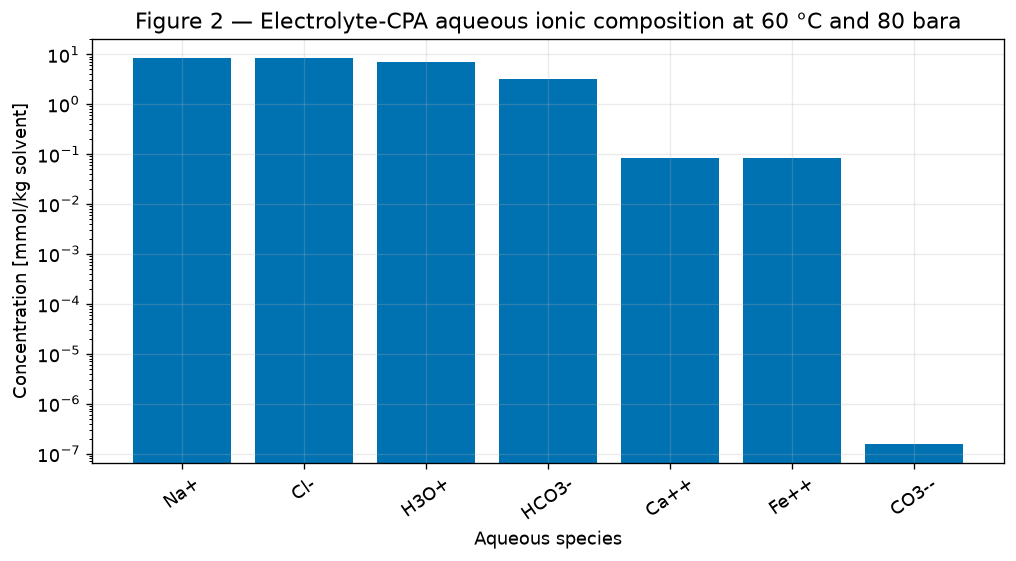

In [7]:
plot_ions = ion_table.loc[
    ion_table["Component"].isin(
        [
            "Na+",
            "Cl-",
            "Ca++",
            "Fe++",
            "H3O+",
            "HCO3-",
            "CO3--",
        ]
    )
].copy()
plot_ions = plot_ions.sort_values(
    "mmol/kgSolvent",
    ascending=False,
)

figure, axis = plt.subplots()
axis.bar(
    plot_ions["Component"],
    plot_ions["mmol/kgSolvent"],
    color=COLORS["blue"],
)
axis.set_yscale("log")
axis.set_xlabel("Aqueous species")
axis.set_ylabel("Concentration [mmol/kg solvent]")
axis.set_title(
    "Figure 2 — Electrolyte-CPA aqueous ionic composition at 60 °C and 80 bara"
)
axis.tick_params(
    axis="x",
    rotation=35,
)
plt.tight_layout()
plt.show()

## Thermodynamic CO₂ corrosion analyzer

`CO2CorrosionAnalyzer` constructs an electrolyte thermodynamic system, checks whether free water
exists, retrieves aqueous pH and CO₂ partitioning, and evaluates a de Waard–Milliams-type carbon
steel corrosion model. This makes the phase check and rate screen reproducible within one object.

The model can still report a notional rate when no aqueous phase exists. In engineering use,
`isFreeWaterPresent()` is therefore a mandatory applicability gate: a dry-gas result is reported
as **not applicable**, not as a physical zero-risk guarantee.

In [8]:
CO2CorrosionAnalyzer = (
    jneqsim.pvtsimulation.flowassurance.CO2CorrosionAnalyzer
)


def run_thermodynamic_corrosion_case(
    temperature_c,
    pressure_bara,
    co2_mole_fraction,
    water_mole_fraction,
    flow_velocity_m_s,
    inhibitor_efficiency=0.0,
):
    analyzer = CO2CorrosionAnalyzer()
    analyzer.setTemperatureCelsius(temperature_c)
    analyzer.setPressureBara(pressure_bara)
    analyzer.setCO2MoleFractionInGas(co2_mole_fraction)
    analyzer.setMethaneMoleFractionInGas(
        0.97 - water_mole_fraction
    )
    analyzer.setN2MoleFractionInGas(0.019)
    analyzer.setWaterMoleFractionInGas(water_mole_fraction)
    analyzer.setFlowVelocity(flow_velocity_m_s)
    analyzer.setPipeDiameter(0.254)
    analyzer.setGlycolFraction(0.0)
    analyzer.setInhibitorEfficiency(inhibitor_efficiency)
    analyzer.run()

    free_water = bool(analyzer.isFreeWaterPresent())
    raw_rate_mm_yr = float(analyzer.getCorrosionRate())
    applicable_rate_mm_yr = (
        raw_rate_mm_yr
        if free_water
        else np.nan
    )

    return {
        "Free water": free_water,
        "Phases [-]": int(analyzer.getNumberOfPhases()),
        "Aqueous pH [-]": (
            float(analyzer.getAqueousPH())
            if free_water
            else np.nan
        ),
        "CO₂ partial pressure [bar]": float(
            analyzer.getCO2PartialPressure()
        ),
        "Baseline rate [mm/yr]": float(
            analyzer.getBaselineCorrosionRate()
        ),
        "Applicable rate [mm/yr]": applicable_rate_mm_yr,
        "Severity": str(analyzer.getCorrosionSeverity()),
    }

In [9]:
thermodynamic_cases = pd.DataFrame(
    [
        {
            "Case": "Wet production fluid",
            **run_thermodynamic_corrosion_case(
                temperature_c=60.0,
                pressure_bara=80.0,
                co2_mole_fraction=0.011,
                water_mole_fraction=0.079,
                flow_velocity_m_s=2.0,
            ),
        },
        {
            "Case": "Single-phase dry gas",
            **run_thermodynamic_corrosion_case(
                temperature_c=60.0,
                pressure_bara=80.0,
                co2_mole_fraction=0.011,
                water_mole_fraction=0.001,
                flow_velocity_m_s=2.0,
            ),
        },
    ]
)

display(thermodynamic_cases)

                   Case  Free water  ...  Applicable rate [mm/yr]   Severity
0  Wet production fluid        True  ...                 3.786001  Very High
1  Single-phase dry gas       False  ...                      NaN  Very High

[2 rows x 8 columns]


## NORSOK M-506 screening model

NeqSim's `NorsokM506CorrosionRate` exposes baseline and corrected rates together with the
individual pH, scale, flow, glycol, and inhibitor corrections:

$$
CR_{\mathrm{corr}}=CR_0 F_{\mathrm{pH}}F_{\mathrm{scale}}F_{\mathrm{flow}}F_{\mathrm{glycol}}(1-\eta)
$$

$CR_{\mathrm{corr}}$ and $CR_0$ are in mm/yr. The $F$ terms and inhibitor efficiency $\eta$ are
dimensionless. Inputs include absolute pressure, gas composition, aqueous chemistry, fluid
properties, pipe diameter, and velocity. The model is a screening method; localized corrosion,
water wetting, transient chemistry, and inhibitor transport require additional assessment.

In [10]:
NorsokM506CorrosionRate = (
    jneqsim.process.corrosion.NorsokM506CorrosionRate
)


def run_norsok_case(
    temperature_c,
    pressure_bara,
    co2_mole_fraction,
    velocity_m_s,
    actual_ph=None,
    inhibitor_efficiency=0.0,
):
    model = NorsokM506CorrosionRate()
    model.setTemperatureCelsius(temperature_c)
    model.setTotalPressureBara(pressure_bara)
    model.setCO2MoleFraction(co2_mole_fraction)
    model.setH2SMoleFraction(0.0)
    model.setBicarbonateConcentrationMgL(250.0)
    model.setIonicStrengthMolL(0.30)
    model.setFlowVelocityMs(velocity_m_s)
    model.setPipeDiameterM(0.254)
    model.setLiquidDensityKgM3(1_000.0)
    model.setLiquidViscosityPas(0.001)
    model.setGlycolWeightFraction(0.0)
    model.setInhibitorEfficiency(inhibitor_efficiency)

    if actual_ph is not None:
        model.setActualPH(actual_ph)

    model.calculate()

    return {
        "Baseline rate [mm/yr]": float(
            model.getBaselineCorrosionRate()
        ),
        "Corrected rate [mm/yr]": float(
            model.getCorrectedCorrosionRate()
        ),
        "Effective pH [-]": float(model.getEffectivePH()),
        "CO₂ fugacity [bar]": float(model.getCO2FugacityBar()),
        "pH factor [-]": float(model.getPHCorrectionFactor()),
        "Scale factor [-]": float(model.getScaleCorrectionFactor()),
        "Flow factor [-]": float(model.getFlowCorrectionFactor()),
        "Glycol factor [-]": float(model.getGlycolCorrectionFactor()),
        "Wall shear stress [Pa]": float(
            model.getWallShearStressPa()
        ),
        "Severity": str(model.getCorrosionSeverity()),
    }

                 Quantity      Value
0   Baseline rate [mm/yr]   4.020875
1  Corrected rate [mm/yr]  19.045324
2        Effective pH [-]   4.793687
3      CO₂ fugacity [bar]   0.805721
4           pH factor [-]   1.837216
5        Scale factor [-]        1.0
6         Flow factor [-]   2.578146
7       Glycol factor [-]        1.0
8  Wall shear stress [Pa]   6.646838
9                Severity  Very High


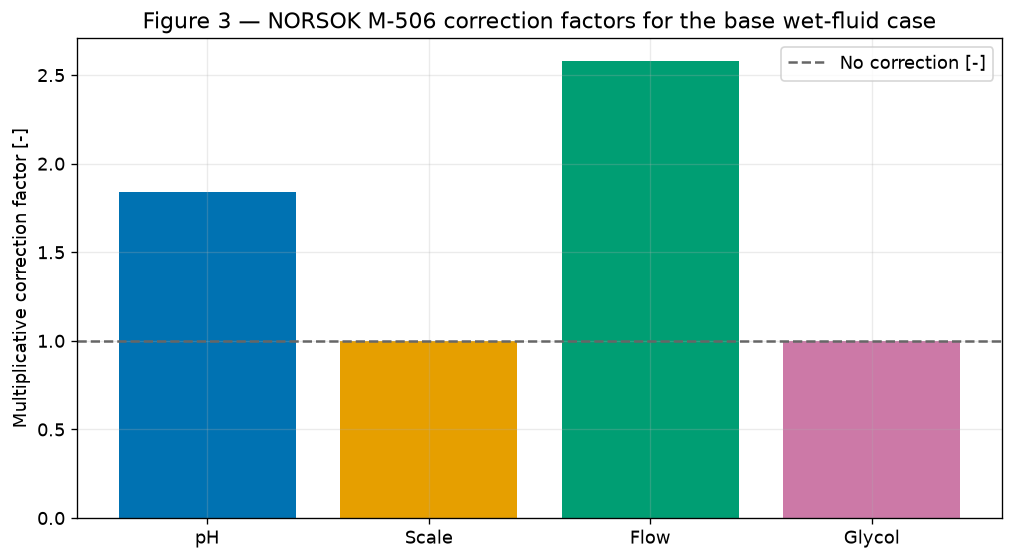

In [11]:
base_norsok = run_norsok_case(
    temperature_c=60.0,
    pressure_bara=80.0,
    co2_mole_fraction=0.011,
    velocity_m_s=2.0,
    actual_ph=aqueous_ph,
)

base_norsok_table = pd.DataFrame(
    {
        "Quantity": list(base_norsok.keys()),
        "Value": list(base_norsok.values()),
    }
)
display(base_norsok_table)

factor_names = [
    "pH factor [-]",
    "Scale factor [-]",
    "Flow factor [-]",
    "Glycol factor [-]",
]
factor_values = [
    base_norsok[name]
    for name in factor_names
]

figure, axis = plt.subplots()
axis.bar(
    [name.replace(" factor [-]", "") for name in factor_names],
    factor_values,
    color=[
        COLORS["blue"],
        COLORS["orange"],
        COLORS["green"],
        COLORS["purple"],
    ],
)
axis.axhline(
    1.0,
    color=COLORS["grey"],
    linestyle="--",
    label="No correction [-]",
)
axis.set_ylabel("Multiplicative correction factor [-]")
axis.set_title(
    "Figure 3 — NORSOK M-506 correction factors for the base wet-fluid case"
)
axis.legend()
plt.tight_layout()
plt.show()

The factor plot makes model causality visible. A value below one reduces the baseline result; a
value above one increases it. The effective pH comes directly from the Electrolyte-CPA calculation,
so the thermodynamic and corrosion models share a documented state rather than an arbitrary pH.

## Temperature, velocity, and CO₂ sensitivity

A rate is meaningful only with its operating envelope. The following grid keeps water chemistry
and pressure fixed while varying one driver at a time. Expected directional trends are checked
later, but non-monotonic temperature behavior can occur when protective-film corrections become
important.

In [12]:
temperature_grid_c = np.array(
    [
        20.0,
        35.0,
        50.0,
        65.0,
        80.0,
        95.0,
    ]
)
velocity_grid_m_s = np.array(
    [
        0.25,
        0.5,
        1.0,
        2.0,
        3.0,
        4.0,
    ]
)
co2_grid_mol_percent = np.array(
    [
        0.2,
        0.5,
        1.1,
        2.0,
        3.5,
        5.0,
    ]
)

temperature_rates = [
    run_norsok_case(
        temperature_c=value,
        pressure_bara=80.0,
        co2_mole_fraction=0.011,
        velocity_m_s=2.0,
        actual_ph=aqueous_ph,
    )["Corrected rate [mm/yr]"]
    for value in temperature_grid_c
]
velocity_rates = [
    run_norsok_case(
        temperature_c=60.0,
        pressure_bara=80.0,
        co2_mole_fraction=0.011,
        velocity_m_s=value,
        actual_ph=aqueous_ph,
    )["Corrected rate [mm/yr]"]
    for value in velocity_grid_m_s
]
co2_rates = [
    run_norsok_case(
        temperature_c=60.0,
        pressure_bara=80.0,
        co2_mole_fraction=value / 100.0,
        velocity_m_s=2.0,
        actual_ph=aqueous_ph,
    )["Corrected rate [mm/yr]"]
    for value in co2_grid_mol_percent
]

sensitivity_summary = pd.DataFrame(
    {
        "Variable": ["Temperature", "Velocity", "CO₂ in gas"],
        "Minimum rate [mm/yr]": [
            min(temperature_rates),
            min(velocity_rates),
            min(co2_rates),
        ],
        "Maximum rate [mm/yr]": [
            max(temperature_rates),
            max(velocity_rates),
            max(co2_rates),
        ],
    }
)
display(sensitivity_summary)

      Variable  Minimum rate [mm/yr]  Maximum rate [mm/yr]
0  Temperature              2.744916             61.660548
1     Velocity              7.387216             35.539831
2   CO₂ in gas             10.848994             31.414537


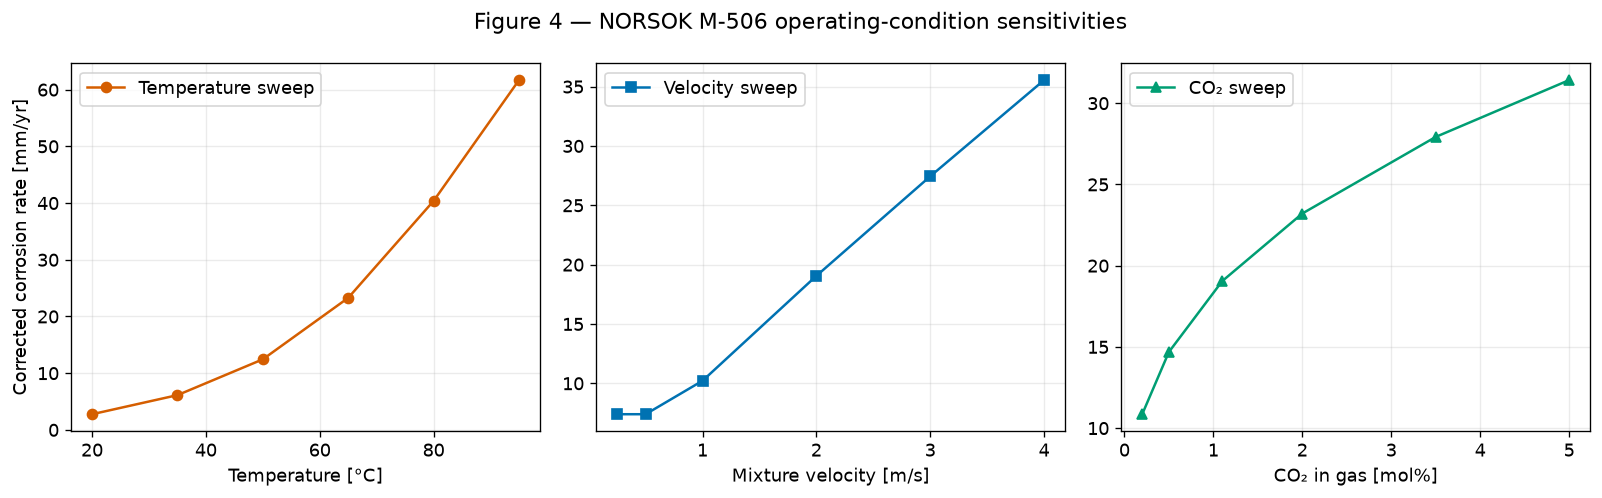

In [13]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(13.5, 4.2),
)

axes[0].plot(
    temperature_grid_c,
    temperature_rates,
    marker="o",
    color=COLORS["red"],
    label="Temperature sweep",
)
axes[0].set_xlabel("Temperature [°C]")
axes[0].set_ylabel("Corrected corrosion rate [mm/yr]")

axes[1].plot(
    velocity_grid_m_s,
    velocity_rates,
    marker="s",
    color=COLORS["blue"],
    label="Velocity sweep",
)
axes[1].set_xlabel("Mixture velocity [m/s]")

axes[2].plot(
    co2_grid_mol_percent,
    co2_rates,
    marker="^",
    color=COLORS["green"],
    label="CO₂ sweep",
)
axes[2].set_xlabel("CO₂ in gas [mol%]")

for axis in axes:
    axis.legend()

figure.suptitle(
    "Figure 4 — NORSOK M-506 operating-condition sensitivities",
)
plt.tight_layout()
plt.show()

## Mechanistic mixed-control model

`MechanisticCorrosionModel` separates the surface-reaction limit from transport of dissolved CO₂
through the liquid boundary layer. Its turbulent-pipe mass-transfer correlation is:

$$
\mathrm{Sh}=0.0165\,\mathrm{Re}^{0.86}\mathrm{Sc}^{0.33}
$$

The kinetic and mass-transfer limits combine as resistances:

$$
\frac{1}{r_{\mathrm{mix}}}=\frac{1}{r_{\mathrm{kin}}}+\frac{1}{r_{\mathrm{mt}}}
$$

For a Langmuir film-forming inhibitor:

$$
\theta=\frac{K_{\mathrm{ads}}(T)C}{1+K_{\mathrm{ads}}(T)C}
$$

The inhibited rate is:

$$
r_{\mathrm{inh}}=r_{\mathrm{mix}}(1-\eta_{\max}\theta)
$$

$\mathrm{Re}$, $\mathrm{Sc}$, and $\mathrm{Sh}$ are dimensionless; $r$ is in mm/yr; $\theta$ is
surface coverage; $C$ is inhibitor dose in mg/L; and $K_{\mathrm{ads}}$ is the temperature-dependent
adsorption coefficient in L/mg. The default isotherm is illustrative and should be calibrated.

In [14]:
MechanisticCorrosionModel = (
    jneqsim.process.chemistry.corrosion.MechanisticCorrosionModel
)
LangmuirInhibitorIsotherm = (
    jneqsim.process.chemistry.corrosion.LangmuirInhibitorIsotherm
)


def run_mechanistic_case(
    temperature_c,
    inhibitor_dose_mg_l,
    flow_velocity_m_s=2.0,
):
    inhibitor_model = LangmuirInhibitorIsotherm()
    model = MechanisticCorrosionModel()
    model.setTemperatureCelsius(temperature_c)
    model.setTotalPressureBara(80.0)
    model.setGasComposition(1.1, 0.0)
    model.setWaterChemistry(
        aqueous_ph,
        250.0,
        300.0,
    )
    model.setFlow(
        flow_velocity_m_s,
        0.254,
        1_000.0,
        0.001,
    )
    model.setInhibitor(
        inhibitor_model,
        inhibitor_dose_mg_l,
    )
    model.evaluate()

    return {
        "Kinetic rate [mm/yr]": float(
            model.getKineticRateMmYr()
        ),
        "Mass-transfer limit [mm/yr]": float(
            model.getMassTransferLimitedRateMmYr()
        ),
        "Mixed-control rate [mm/yr]": float(
            model.getMixedControlRateMmYr()
        ),
        "Inhibited rate [mm/yr]": float(
            model.getInhibitedRateMmYr()
        ),
        "Reynolds number [-]": float(model.getReynoldsNumber()),
        "Schmidt number [-]": float(model.getSchmidtNumber()),
        "Sherwood number [-]": float(model.getSherwoodNumber()),
        "Coverage [-]": float(model.getInhibitorCoverage()),
        "Efficiency [-]": float(model.getInhibitorEfficiency()),
    }

In [15]:
mechanistic_base = run_mechanistic_case(
    temperature_c=60.0,
    inhibitor_dose_mg_l=50.0,
)
display(
    pd.DataFrame(
        {
            "Quantity": list(mechanistic_base.keys()),
            "Value": list(mechanistic_base.values()),
        }
    )
)

inhibitor_dose_grid_mg_l = np.linspace(
    0.0,
    200.0,
    21,
)
inhibitor_temperatures_c = [
    30.0,
    60.0,
    90.0,
]

inhibitor_results = {}
for temperature_c in inhibitor_temperatures_c:
    inhibitor_results[temperature_c] = [
        run_mechanistic_case(
            temperature_c=temperature_c,
            inhibitor_dose_mg_l=dose_mg_l,
        )
        for dose_mg_l in inhibitor_dose_grid_mg_l
    ]

                      Quantity          Value
0         Kinetic rate [mm/yr]       0.545134
1  Mass-transfer limit [mm/yr]       3.122798
2   Mixed-control rate [mm/yr]       0.464115
3       Inhibited rate [mm/yr]       0.402630
4          Reynolds number [-]  508000.000000
5           Schmidt number [-]     431.952929
6          Sherwood number [-]    9867.809489
7                 Coverage [-]       0.139452
8               Efficiency [-]       0.132479


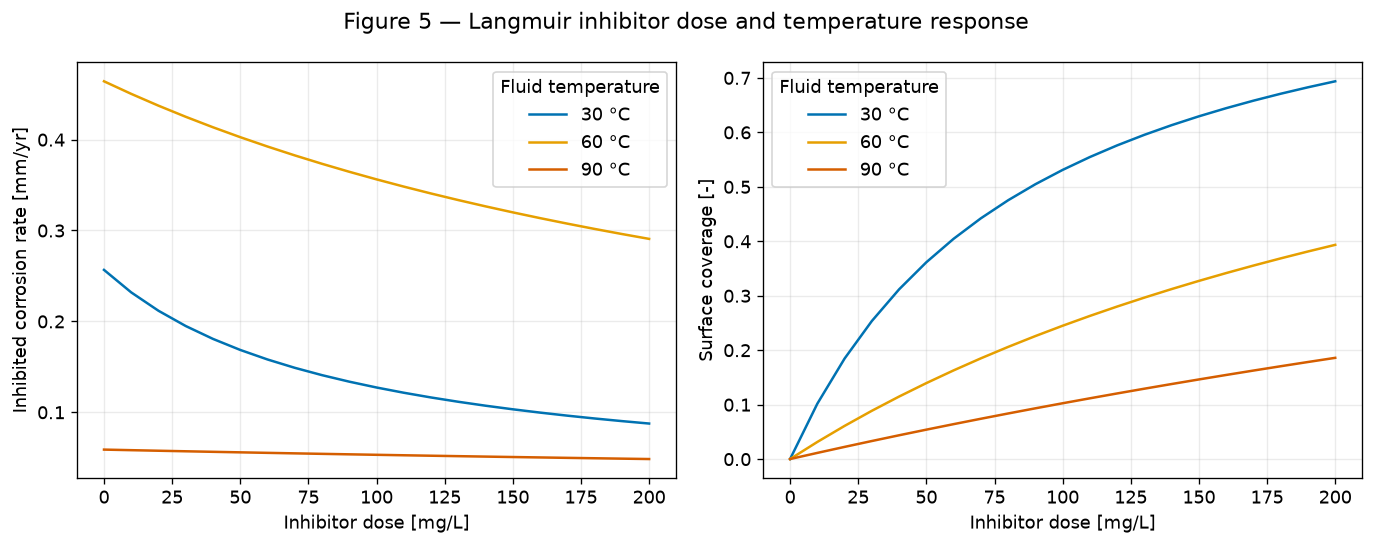

In [16]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(11.6, 4.6),
)

for temperature_c, color in zip(
    inhibitor_temperatures_c,
    [
        COLORS["blue"],
        COLORS["orange"],
        COLORS["red"],
    ],
):
    rates = [
        result["Inhibited rate [mm/yr]"]
        for result in inhibitor_results[temperature_c]
    ]
    coverage = [
        result["Coverage [-]"]
        for result in inhibitor_results[temperature_c]
    ]
    label = f"{temperature_c:.0f} °C"
    axes[0].plot(
        inhibitor_dose_grid_mg_l,
        rates,
        label=label,
        color=color,
    )
    axes[1].plot(
        inhibitor_dose_grid_mg_l,
        coverage,
        label=label,
        color=color,
    )

axes[0].set_xlabel("Inhibitor dose [mg/L]")
axes[0].set_ylabel("Inhibited corrosion rate [mm/yr]")
axes[1].set_xlabel("Inhibitor dose [mg/L]")
axes[1].set_ylabel("Surface coverage [-]")

for axis in axes:
    axis.legend(title="Fluid temperature")

figure.suptitle(
    "Figure 5 — Langmuir inhibitor dose and temperature response",
)
plt.tight_layout()
plt.show()

The mixed-control result is below both individual limiting rates, as required by the resistance
formulation. Coverage increases with dose but shows diminishing returns. Temperature changes both
uninhibited kinetics and adsorption, so a single inhibitor efficiency should not be extrapolated
across a wide operating envelope without qualification.

## Material selection and sour-service screening

Corrosion rate alone does not determine metallurgy. NeqSim's NORSOK M-001 material selector
combines free water, CO₂ rate, chloride, temperature, and design life. The ISO 15156-style sour
service assessment separately screens sulfide stress cracking and hydrogen-induced cracking.

The following sour case deliberately uses **0.01 bar H₂S partial pressure** to demonstrate the
workflow. It is not the base sweet-fluid composition.

In [17]:
NorsokM001MaterialSelection = (
    jneqsim.process.corrosion.NorsokM001MaterialSelection
)
SourServiceAssessment = (
    jneqsim.process.corrosion.SourServiceAssessment
)

material_selector = NorsokM001MaterialSelection()
material_selector.setCO2CorrosionRateMmyr(
    base_norsok["Corrected rate [mm/yr]"]
)
material_selector.setCO2PartialPressureBar(
    base_norsok["CO₂ fugacity [bar]"]
)
material_selector.setAqueousPH(aqueous_ph)
material_selector.setH2SPartialPressureBar(0.0)
material_selector.setChlorideConcentrationMgL(300.0)
material_selector.setDesignTemperatureC(60.0)
material_selector.setMaxDesignTemperatureC(90.0)
material_selector.setDesignLifeYears(DESIGN_LIFE_YEARS)
material_selector.setFreeWaterPresent(True)
material_selector.evaluate()

sour_assessment = SourServiceAssessment()
sour_assessment.setTotalPressureBar(80.0)
sour_assessment.setCO2PartialPressureBar(
    base_norsok["CO₂ fugacity [bar]"]
)
sour_assessment.setH2SPartialPressureBar(0.01)
sour_assessment.setInSituPH(aqueous_ph)
sour_assessment.setTemperatureC(60.0)
sour_assessment.setChlorideConcentrationMgL(300.0)
sour_assessment.setFreeWaterPresent(True)
sour_assessment.setMaterialGrade("API 5L X65")
sour_assessment.setYieldStrengthMPa(450.0)
sour_assessment.setHardnessHRC(20.0)
sour_assessment.setPWHTApplied(False)
sour_assessment.evaluate()

material_results = pd.DataFrame(
    [
        {
            "Assessment": "Sweet CO₂ service",
            "Classification": str(
                material_selector.getServiceCategory()
            ),
            "Recommendation": str(
                material_selector.getRecommendedMaterial()
            ),
        },
        {
            "Assessment": "Demonstration sour case",
            "Classification": (
                f"ISO 15156 region "
                f"{sour_assessment.getSourRegion()}"
            ),
            "Recommendation": str(
                sour_assessment.getRecommendedMaterial()
            ),
        },
    ]
)
display(material_results)

                Assessment  ...                                     Recommendation
0        Sweet CO₂ service  ...                        22Cr Duplex SS (UNS S31803)
1  Demonstration sour case  ...  HIC-resistant carbon steel + PWHT (or 22Cr dup...

[2 rows x 3 columns]


## Final application: wet-gas flowline to integrity profile

The final workflow connects a CPA wet-gas fluid to a `Stream` and `PipeBeggsAndBrills`. The pipe
calculates pressure, temperature, gas and liquid superficial velocities, and liquid holdup along
the line. The local mixture velocity, pressure, and temperature are then supplied to a separate
NORSOK M-506 calculation at each hydraulic node.

This is a screening coupling rather than a fully compositional corrosion transport model:
segment pH is calculated by the corrosion model, while bicarbonate and ionic strength remain fixed.
The purpose is to identify where detailed sampling, inhibitor verification, and inspection should
be concentrated.

In [18]:
flowline_fluid = fluid(
    "cpa",
    temperature=333.15,
    pressure=120.0,
)
flowline_composition = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.840,
    "ethane": 0.050,
    "propane": 0.025,
    "n-butane": 0.010,
    "n-pentane": 0.005,
    "water": 0.040,
}

for component_name, component_amount in flowline_composition.items():
    flowline_fluid.addComponent(
        component_name,
        component_amount,
    )

flowline_fluid.setMixingRule(10)
flowline_fluid.setMultiPhaseCheck(True)

flowline_feed = stream(
    "wet production fluid",
    flowline_fluid,
)
flowline_feed.setFlowRate(
    PIPE_FEED_RATE_KG_S,
    "kg/sec",
)
flowline_feed.run()

production_flowline = beggs_brill_pipe(
    "20 km wet-gas flowline",
    flowline_feed,
    length=PIPE_LENGTH_M,
    diameter=PIPE_DIAMETER_M,
    elevation=80.0,
    roughness=5.0e-5,
)
production_flowline.setNumberOfIncrements(12)
production_flowline.setConstantSurfaceTemperature(
    5.0,
    "C",
)
production_flowline.setHeatTransferCoefficient(12.0)
production_flowline.run()

print(
    "Outlet pressure:",
    f"{production_flowline.getOutletStream().getPressure('bara'):.3f} bara",
)
print(
    "Outlet temperature:",
    f"{production_flowline.getOutletStream().getTemperature('C'):.3f} °C",
)

Outlet pressure: 115.085 bara
Outlet temperature: 6.475 °C


In [19]:
distance_km = (
    np.asarray(
        production_flowline.getLengthProfile(),
        dtype=float,
    )
    / 1_000.0
)
pressure_profile_bara = np.asarray(
    production_flowline.getPressureProfile(),
    dtype=float,
)
temperature_profile_c = (
    np.asarray(
        production_flowline.getTemperatureProfile(),
        dtype=float,
    )
    - 273.15
)
mixture_velocity_profile_m_s = np.asarray(
    production_flowline.getMixtureSuperficialVelocityProfile(),
    dtype=float,
)
liquid_velocity_profile_m_s = np.asarray(
    production_flowline.getLiquidSuperficialVelocityProfile(),
    dtype=float,
)
liquid_holdup_profile = np.asarray(
    production_flowline.getLiquidHoldupProfile(),
    dtype=float,
)

hydraulic_profile = pd.DataFrame(
    {
        "Distance [km]": distance_km,
        "Pressure [bara]": pressure_profile_bara,
        "Temperature [°C]": temperature_profile_c,
        "Mixture velocity [m/s]": mixture_velocity_profile_m_s,
        "Liquid superficial velocity [m/s]": (
            liquid_velocity_profile_m_s
        ),
        "Liquid holdup [-]": liquid_holdup_profile,
    }
)
display(hydraulic_profile)

    Distance [km]  ...  Liquid holdup [-]
0        0.000000  ...           0.058214
1        1.666667  ...           0.061879
2        3.333333  ...           0.064746
3        5.000000  ...           0.067016
4        6.666667  ...           0.068791
5        8.333333  ...           0.070160
6       10.000000  ...           0.071202
7       11.666667  ...           0.071980
8       13.333333  ...           0.072547
9       15.000000  ...           0.072947
10      16.666667  ...           0.073215
11      18.333333  ...           0.073379
12      20.000000  ...           0.073461

[13 rows x 6 columns]


In [20]:
uninhibited_profile_mm_yr = []
inhibited_profile_mm_yr = []
segment_ph = []
segment_shear_pa = []

for temperature_c, pressure_bara, velocity_m_s in zip(
    temperature_profile_c,
    pressure_profile_bara,
    mixture_velocity_profile_m_s,
):
    uninhibited = run_norsok_case(
        temperature_c=float(temperature_c),
        pressure_bara=float(pressure_bara),
        co2_mole_fraction=0.020,
        velocity_m_s=float(velocity_m_s),
        actual_ph=None,
        inhibitor_efficiency=0.0,
    )
    inhibited = run_norsok_case(
        temperature_c=float(temperature_c),
        pressure_bara=float(pressure_bara),
        co2_mole_fraction=0.020,
        velocity_m_s=float(velocity_m_s),
        actual_ph=None,
        inhibitor_efficiency=0.90,
    )
    uninhibited_profile_mm_yr.append(
        uninhibited["Corrected rate [mm/yr]"]
    )
    inhibited_profile_mm_yr.append(
        inhibited["Corrected rate [mm/yr]"]
    )
    segment_ph.append(uninhibited["Effective pH [-]"])
    segment_shear_pa.append(
        uninhibited["Wall shear stress [Pa]"]
    )

uninhibited_profile_mm_yr = np.asarray(
    uninhibited_profile_mm_yr
)
inhibited_profile_mm_yr = np.asarray(
    inhibited_profile_mm_yr
)
segment_ph = np.asarray(segment_ph)
segment_shear_pa = np.asarray(segment_shear_pa)

integrity_profile = hydraulic_profile.copy()
integrity_profile["Effective pH [-]"] = segment_ph
integrity_profile["Wall shear stress [Pa]"] = segment_shear_pa
integrity_profile["Uninhibited rate [mm/yr]"] = (
    uninhibited_profile_mm_yr
)
integrity_profile["90% inhibited rate [mm/yr]"] = (
    inhibited_profile_mm_yr
)
integrity_profile["25-year inhibited uniform loss [mm]"] = (
    inhibited_profile_mm_yr * DESIGN_LIFE_YEARS
)

display(integrity_profile)

maximum_loss_index = int(
    np.argmax(
        integrity_profile[
            "25-year inhibited uniform loss [mm]"
        ].to_numpy()
    )
)
maximum_loss_mm = float(
    integrity_profile.loc[
        maximum_loss_index,
        "25-year inhibited uniform loss [mm]",
    ]
)
maximum_loss_distance_km = float(
    integrity_profile.loc[
        maximum_loss_index,
        "Distance [km]",
    ]
)

print(
    "Maximum screened 25-year inhibited uniform loss:",
    f"{maximum_loss_mm:.3f} mm",
)
print(
    "Location of maximum screened loss:",
    f"{maximum_loss_distance_km:.3f} km from inlet",
)

    Distance [km]  ...  25-year inhibited uniform loss [mm]
0        0.000000  ...                            69.078811
1        1.666667  ...                            37.284079
2        3.333333  ...                            22.795929
3        5.000000  ...                            15.545322
4        6.666667  ...                            11.573900
5        8.333333  ...                             9.229191
6       10.000000  ...                             7.759449
7       11.666667  ...                             6.793675
8       13.333333  ...                             6.135508
9       15.000000  ...                             5.674337
10      16.666667  ...                             5.344391
11      18.333333  ...                             5.104697
12      20.000000  ...                             4.928699

[13 rows x 11 columns]
Maximum screened 25-year inhibited uniform loss: 69.079 mm
Location of maximum screened loss: 0.000 km from inlet


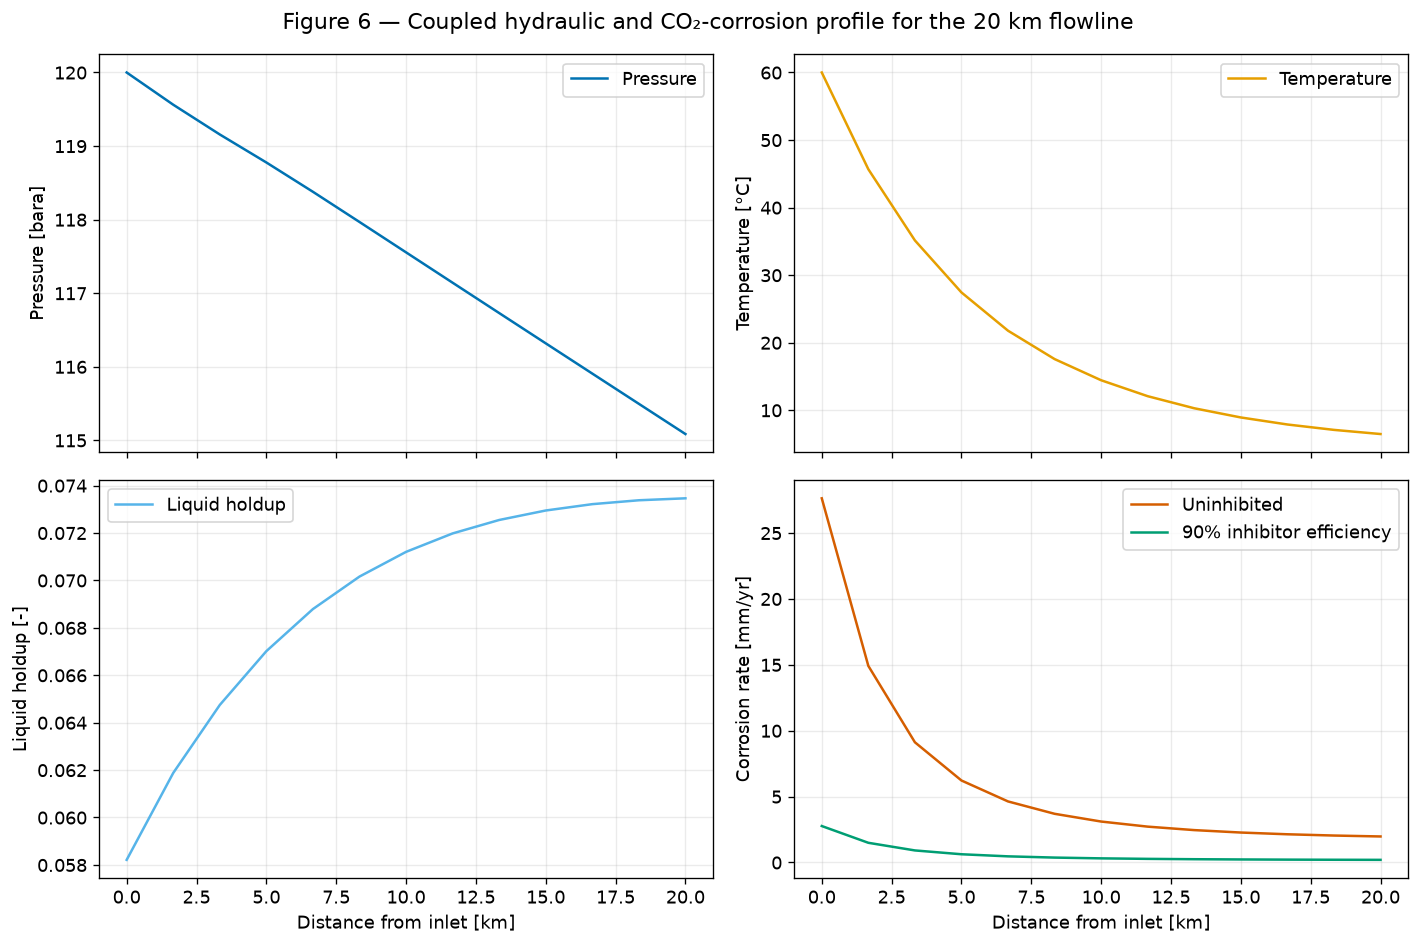

In [21]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 8.0),
    sharex=True,
)

axes[0, 0].plot(
    distance_km,
    pressure_profile_bara,
    color=COLORS["blue"],
    label="Pressure",
)
axes[0, 0].set_ylabel("Pressure [bara]")

axes[0, 1].plot(
    distance_km,
    temperature_profile_c,
    color=COLORS["orange"],
    label="Temperature",
)
axes[0, 1].set_ylabel("Temperature [°C]")

axes[1, 0].plot(
    distance_km,
    liquid_holdup_profile,
    color=COLORS["sky"],
    label="Liquid holdup",
)
axes[1, 0].set_xlabel("Distance from inlet [km]")
axes[1, 0].set_ylabel("Liquid holdup [-]")

axes[1, 1].plot(
    distance_km,
    uninhibited_profile_mm_yr,
    color=COLORS["red"],
    label="Uninhibited",
)
axes[1, 1].plot(
    distance_km,
    inhibited_profile_mm_yr,
    color=COLORS["green"],
    label="90% inhibitor efficiency",
)
axes[1, 1].set_xlabel("Distance from inlet [km]")
axes[1, 1].set_ylabel("Corrosion rate [mm/yr]")

for axis in axes.flat:
    axis.legend()

figure.suptitle(
    "Figure 6 — Coupled hydraulic and CO₂-corrosion profile for the 20 km flowline"
)
plt.tight_layout()
plt.show()

The inlet is warmest and has the highest pressure, so this synthetic case places the largest
screened rate near the upstream end. Cooling reduces the rate along the line, while liquid holdup
increases slightly. Even with the assumed 90% efficiency, the maximum screened 25-year uniform
loss is about **69 mm** at the inlet. This is not an acceptable carbon-steel design basis and
supports the separate material-selector recommendation for a corrosion-resistant alloy. The 90%
curve is a specified performance target; it is not a guarantee that inhibitor reaches every wetted
location during shutdowns or low flow.

For an integrity plan, use the profile to choose monitoring locations, then evaluate transient
water wetting, dead legs, low points, inhibitor transport, localized attack, and upset exposure.

## Verification checks

The assertions below test solver completion, physical finiteness, expected phase behavior, model
identities, inhibition response, hydraulic direction, and profile consistency. They are deliberately
focused on engineering behavior rather than exact machine-dependent rounding.

In [22]:
engineering_checks = {
    "Electrolyte flash has gas and aqueous phases": (
        electrolyte_system.getNumberOfPhases() >= 2
    ),
    "Aqueous pH is finite and within model range": (
        np.isfinite(aqueous_ph)
        and 3.5 <= aqueous_ph <= 6.5
    ),
    "Ion table contains carbonate species": (
        "HCO3-" in set(ion_table["Component"])
    ),
    "Scale tendency table contains FeCO3": (
        "FeCO3" in set(scale_table["Salt"])
    ),
    "Wet case has free water": bool(
        thermodynamic_cases.loc[0, "Free water"]
    ),
    "Dry case has no free water": not bool(
        thermodynamic_cases.loc[1, "Free water"]
    ),
    "Dry-case corrosion rate is applicability-gated": (
        pd.isna(
            thermodynamic_cases.loc[
                1,
                "Applicable rate [mm/yr]",
            ]
        )
    ),
    "NORSOK base rates are positive": (
        base_norsok["Baseline rate [mm/yr]"] > 0.0
        and base_norsok["Corrected rate [mm/yr]"] > 0.0
    ),
    "Mixed rate is below both limiting rates": (
        mechanistic_base["Mixed-control rate [mm/yr]"]
        <= min(
            mechanistic_base["Kinetic rate [mm/yr]"],
            mechanistic_base["Mass-transfer limit [mm/yr]"],
        )
    ),
    "Inhibitor reduces mechanistic rate": (
        mechanistic_base["Inhibited rate [mm/yr]"]
        < mechanistic_base["Mixed-control rate [mm/yr]"]
    ),
    "Inhibitor coverage is bounded": (
        0.0 <= mechanistic_base["Coverage [-]"] <= 1.0
    ),
    "CO2 sensitivity increases from first to last point": (
        co2_rates[-1] > co2_rates[0]
    ),
    "Flowline pressure decreases": (
        pressure_profile_bara[-1] < pressure_profile_bara[0]
    ),
    "Flowline cools toward ambient": (
        temperature_profile_c[-1] < temperature_profile_c[0]
    ),
    "Hydraulic arrays have matching length": (
        len(distance_km)
        == len(pressure_profile_bara)
        == len(temperature_profile_c)
        == len(inhibited_profile_mm_yr)
    ),
    "All profile results are finite": bool(
        np.isfinite(
            integrity_profile.select_dtypes(
                include=[np.number]
            ).to_numpy()
        ).all()
    ),
    "Specified inhibition reduces every segment rate": bool(
        np.all(
            inhibited_profile_mm_yr
            < uninhibited_profile_mm_yr
        )
    ),
    "Corrosion rates remain non-negative": bool(
        np.all(inhibited_profile_mm_yr >= 0.0)
        and np.all(uninhibited_profile_mm_yr >= 0.0)
    ),
}

check_table = pd.DataFrame(
    {
        "Check": list(engineering_checks.keys()),
        "Passed": list(engineering_checks.values()),
    }
)
display(check_table)

assert all(engineering_checks.values())
print(
    f"All {len(engineering_checks)} engineering checks passed."
)

                                                Check  Passed
0        Electrolyte flash has gas and aqueous phases    True
1         Aqueous pH is finite and within model range    True
2                Ion table contains carbonate species    True
3                 Scale tendency table contains FeCO3    True
4                             Wet case has free water    True
5                          Dry case has no free water    True
6      Dry-case corrosion rate is applicability-gated    True
7                      NORSOK base rates are positive    True
8             Mixed rate is below both limiting rates    True
9                  Inhibitor reduces mechanistic rate    True
10                      Inhibitor coverage is bounded    True
11  CO2 sensitivity increases from first to last p...    True
12                        Flowline pressure decreases    True
13                      Flowline cools toward ambient    True
14              Hydraulic arrays have matching length    True
15      

## Troubleshooting

- **No aqueous phase:** increase water content or cool the fluid, then rerun the TP flash. Do not
  apply an aqueous corrosion rate without confirming water wetting.
- **Unexpected pH:** confirm ion charge balance, component units, mixing rule 10, reaction
  initialization, and whether the aqueous phase exists.
- **Flash convergence:** begin from a nearby pressure and temperature, simplify trace ions, and
  verify that all component amounts are positive and physically meaningful.
- **Extreme corrosion rate:** check absolute versus gauge pressure, gas mole fraction versus
  mol%, velocity units, viscosity in Pa·s, and the NORSOK applicability range.
- **Flat inhibitor response:** verify dose units and calibrate adsorption parameters against
  representative fluid, steel, temperature, shear, and exposure tests.
- **Pipe profile failure:** reduce increment count for diagnosis, verify positive diameter and
  roughness, run the inlet stream first, and inspect the outlet before increasing complexity.

## Limitations and responsible use

This notebook is a screening and teaching workflow. It does not model localized pitting,
microbiologically influenced corrosion, oxygen ingress, erosion-corrosion, galvanic coupling,
deposit morphology, inhibitor partitioning and transport, shutdown water wetting, or inspection
probability of detection. Uniform wall loss is simply rate multiplied by time; real corrosion
rates vary through the asset life.

Material and inhibitor decisions require current standards, representative autoclave or flow-loop
testing, corrosion monitoring, inspection data, operating transients, failure consequences, and
qualified discipline review.

## Summary

- Electrolyte-CPA establishes free water, pH, ionic activities, and scale tendency.
- The thermodynamic analyzer keeps the phase-equilibrium and corrosion screen in one workflow.
- NORSOK M-506 exposes the assumptions and correction factors behind a carbon-steel rate.
- The mechanistic model separates surface kinetics, mass transfer, and inhibitor adsorption.
- Material and sour-service tools turn fluid severity into a first-pass integrity decision.
- Coupling a Beggs–Brill profile to local corrosion calculations identifies critical locations.

### Further exercises

1. Replace the synthetic composition and water analysis with laboratory data.
2. Calibrate the inhibitor isotherm to flow-loop measurements at three temperatures.
3. Compare continuous inhibition with 90%, 95%, and 98% availability over the design life.
4. Add an H₂S sweep and map ISO 15156 sour-service regions.
5. Repeat the pipeline study at turndown and shutdown/restart conditions.
6. Couple inspection intervals to a probabilistic wall-thickness and localized-corrosion model.

## Authoritative references

- NeqSim documentation:
  [Flow assurance and corrosion overview](https://equinor.github.io/neqsim/pvtsimulation/flow_assurance_overview.html)
- NeqSim source documentation:
  [NORSOK M-506 corrosion rate](https://github.com/equinor/neqsim/blob/master/docs/process/corrosion/norsok_m506_corrosion_rate.md)
- NeqSim source documentation:
  [Mechanistic corrosion](https://github.com/equinor/neqsim/blob/master/docs/chemistry/mechanistic_corrosion.md)
- NeqSim source documentation:
  [Pipeline corrosion integration](https://github.com/equinor/neqsim/blob/master/docs/process/corrosion/pipeline_corrosion_integration.md)
- NORSOK M-506, *CO₂ corrosion rate calculation model*.
- NORSOK M-001, *Materials selection*.
- ISO 15156, *Petroleum and natural gas industries — Materials for use in H₂S-containing
  environments in oil and gas production*.
- API RP 14E, *Design and Installation of Offshore Production Platform Piping Systems*.